# NS — Agrupación con K-Means

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 3. Agrupación sobre samsung.csv

Descubrir grupos (clusters) en el comportamiento del precio y volumen de la acción de Samsung (2008–2019) mediante K-Means, optimizando el número de clusters k con métricas de evaluación.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **K-Means** porque buscamos particionar las observaciones (días de cotización) en grupos homogéneos a partir de características numéricas continuas, sin etiquetas previas (aprendizaje no supervisado). K-Means es el algoritmo de agrupación más utilizado por su sencillez y eficiencia; su número de clusters k se puede optimizar objetivamente con la **inercia** (método del codo) y el **coeficiente de silueta**, complementado con el índice de **Davies-Bouldin**.

In [2]:
df = pd.read_csv(os.path.join(DATA, "samsung.csv"))
df.head()

,Date,Close,Volume
0,02/01/2008,10880,18047200
1,03/01/2008,10920,19346500
2,04/01/2008,10780,17997350
3,07/01/2008,10380,39787200
4,08/01/2008,10320,24783700


In [3]:
print("Dimensiones:", df.shape)
print("\nNulos:", df.isna().sum().sum())
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date").reset_index(drop=True)
print("Rango de fechas:", df["Date"].min(), "->", df["Date"].max())
print("\nEstadísticos:\n", df[["Close", "Volume"]].describe().round(2))

Dimensiones: (2850, 3)

Nulos: 0
Rango de fechas: 2008-01-02 00:00:00 -> 2019-06-28 00:00:00

Estadísticos:
           Close       Volume
count   2850.00      2850.00
mean   26611.31  16105048.47
std    11991.61   8661794.32
min     8040.00         0.00
25%    16300.00  10214262.50
50%    25600.00  13590333.00
75%    30850.00  19609700.00
max    57220.00  64873450.00


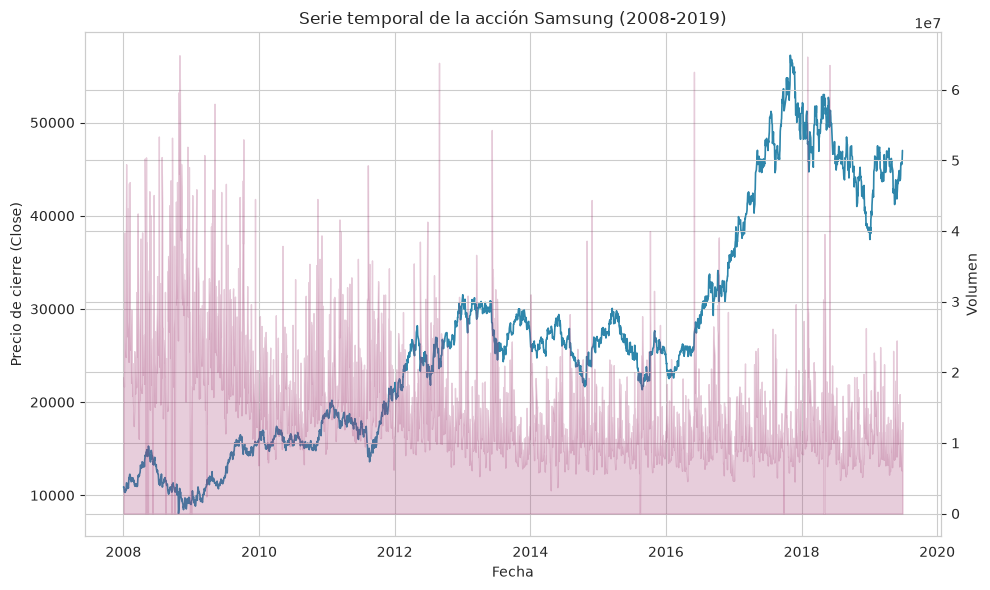

In [4]:
fig, ax1 = plt.subplots()
ax1.plot(df["Date"], df["Close"], color="#2E86AB", linewidth=1.2)
ax1.set_ylabel("Precio de cierre (Close)")
ax1.set_xlabel("Fecha")
ax2 = ax1.twinx()
ax2.fill_between(df["Date"], df["Volume"], alpha=0.25, color="#A23B72")
ax2.set_ylabel("Volumen")
plt.title("Serie temporal de la acción Samsung (2008-2019)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "serie_samsung.png"), dpi=150, bbox_inches="tight")
plt.show()

## Diseño del modelo (paso a paso)

### Ingeniería de características

In [5]:
# Características derivadas: retorno diario, volumen logarítmico y medias móviles
df["retorno"] = df["Close"].pct_change() * 100
df["vol_log"] = np.log1p(df["Volume"])
df["ma5"] = df["Close"].rolling(5).mean()
df["ma20"] = df["Close"].rolling(20).mean()
df = df.dropna().reset_index(drop=True)
features = ["Close", "Volume", "retorno", "vol_log", "ma5", "ma20"]
print("Observaciones tras feature engineering:", df.shape[0])
df[features].describe().round(2)

Observaciones tras feature engineering: 2831


,Close,Volume,retorno,vol_log,ma5,ma20
count,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00
mean,26717.63,16010264.80,0.07,16.40,26692.57,26601.96
std,11961.07,8580088.79,1.89,1.25,11948.77,11918.69
min,8040.00,0.00,-14.92,0.00,8720.00,9106.00
25%,16400.00,10197950.00,-1.02,16.14,16360.00,16179.00
50%,25640.00,13543350.00,0.00,16.42,25644.00,25688.00
75%,30900.00,19503725.00,1.11,16.79,30798.00,30418.50
max,57220.00,64873450.00,13.05,17.99,56628.00,55910.00


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

scaler = StandardScaler()
X = scaler.fit_transform(df[features])
print("Matriz escalada:", X.shape)

Matriz escalada: (2831, 6)


### Optimización — búsqueda del número de clusters k

In [7]:
inercia, sil, db = [], [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))
    db.append(davies_bouldin_score(X, km.labels_))

tabla = pd.DataFrame({"k": range(2, 11), "inercia": np.round(inercia, 2),
                       "silueta": np.round(sil, 4), "davies_bouldin": np.round(db, 4)})
print(tabla)

    k   inercia  silueta  davies_bouldin
0   2  10604.48   0.4510          0.7953
1   3   7935.45   0.3794          1.0393
2   4   5619.45   0.3916          0.8201
3   5   4545.44   0.3933          0.8592
4   6   3848.05   0.3818          0.8339
5   7   3442.56   0.3330          0.8964
6   8   3193.31   0.3409          0.8630
7   9   2947.50   0.3010          1.0045
8  10   2741.43   0.2866          1.0652


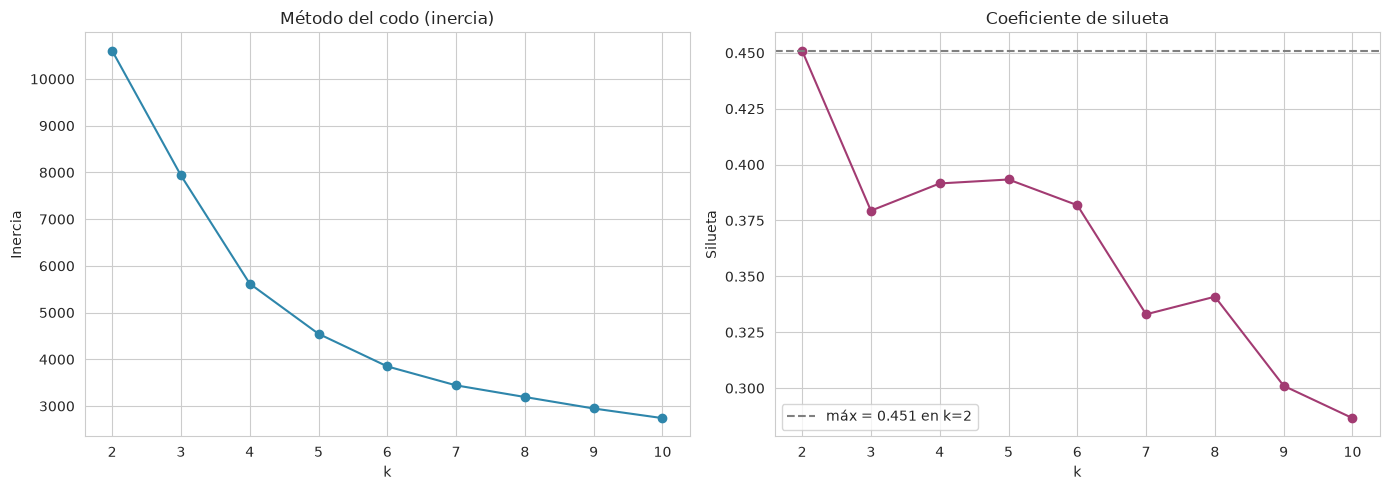

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 11), inercia, marker="o", color="#2E86AB")
axes[0].set_title("Método del codo (inercia)"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia")
axes[1].plot(range(2, 11), sil, marker="o", color="#A23B72")
axes[1].axhline(max(sil), ls="--", color="gray", label=f"máx = {max(sil):.3f} en k={np.argmax(sil)+2}")
axes[1].set_title("Coeficiente de silueta"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silueta")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG, "elbow_silhouette_samsung.png"), dpi=150, bbox_inches="tight")
plt.show()

In [9]:
k_opt = np.argmax(sil) + 2
print("k óptimo por silueta:", k_opt, f"(silueta = {max(sil):.4f})")
print("k óptimo por Davies-Bouldin:", np.argmin(db) + 2, f"(DB = {min(db):.4f})")

k óptimo por silueta: 2 (silueta = 0.4510)
k óptimo por Davies-Bouldin: 2 (DB = 0.7953)


### Entrenamiento final de K-Means

In [10]:
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
kmeans.fit(X)
df["cluster"] = kmeans.labels_
print("Etiquetas asignadas:", np.bincount(kmeans.labels_))

Etiquetas asignadas: [2196  635]


### Visualización de los clusters

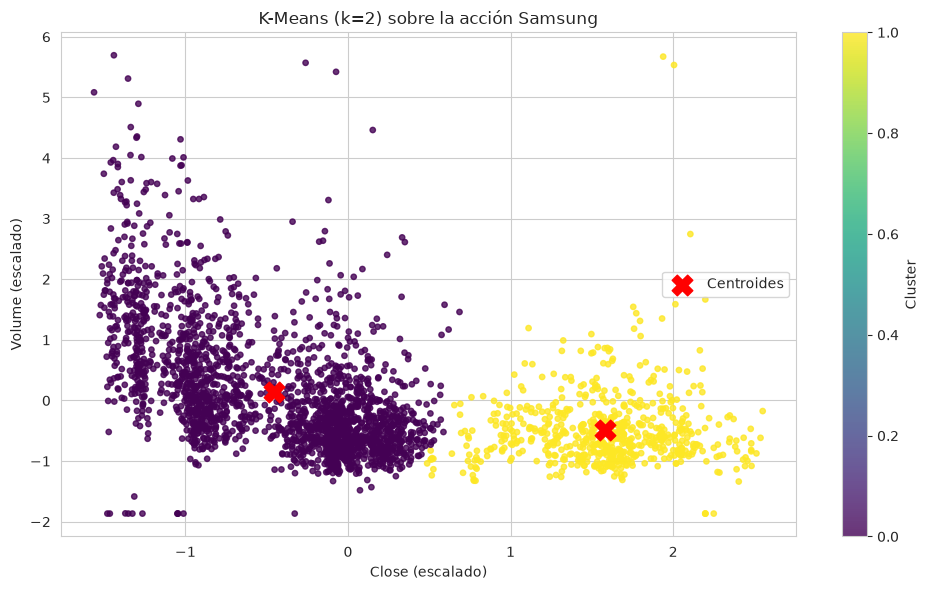

In [11]:
plt.figure()
sc = plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", s=15, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=220, c="red", label="Centroides")
plt.xlabel("Close (escalado)"); plt.ylabel("Volume (escalado)")
plt.title(f"K-Means (k={k_opt}) sobre la acción Samsung")
plt.colorbar(sc, label="Cluster"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG, "clusters_samsung.png"), dpi=150, bbox_inches="tight")
plt.show()

### Interpretación de los clusters

In [12]:
perfil = df.groupby("cluster")[["Close", "Volume", "retorno"]].mean().round(2)
print(perfil)
print("\nInterpretación: cada cluster agrupa días con un comportamiento similar de precio y volumen.")

            Close       Volume  retorno
cluster                                
0        21248.63  17237099.29     0.07
1        45630.87  11767542.67     0.07

Interpretación: cada cluster agrupa días con un comportamiento similar de precio y volumen.


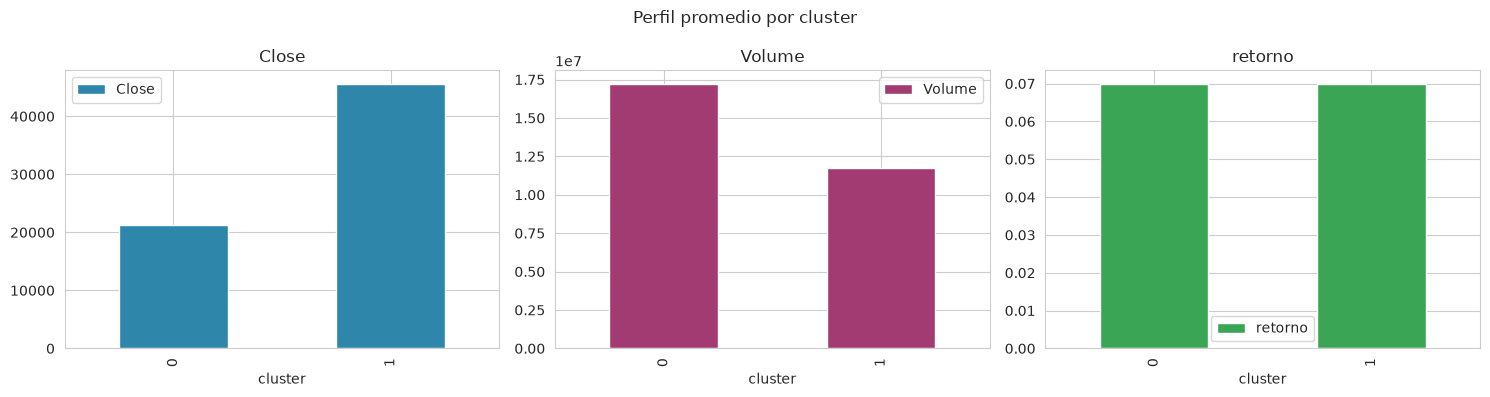

In [13]:
perfil.plot(kind="bar", subplots=True, layout=(1, 3), figsize=(15, 4), color=["#2E86AB", "#A23B72", "#3AA655"])
plt.suptitle("Perfil promedio por cluster")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "perfil_clusters_samsung.png"), dpi=150, bbox_inches="tight")
plt.show()

## Guardar el modelo

In [14]:
import joblib
pipeline = {"scaler": scaler, "kmeans": kmeans, "features": features, "k": k_opt}
joblib.dump(pipeline, os.path.join(MODELOS, "samsung_kmeans.pkl"))
print("Modelo K-Means guardado en modelos/samsung_kmeans.pkl")

Modelo K-Means guardado en modelos/samsung_kmeans.pkl


## Verificación de integridad (recarga del modelo)

In [15]:
p = joblib.load(os.path.join(MODELOS, "samsung_kmeans.pkl"))
X2 = p["scaler"].transform(df[features])
lab = p["kmeans"].predict(X2)
print("k guardado:", p["k"])
print("Clusters reasignados coinciden:", np.array_equal(lab, kmeans.labels_))

k guardado: 2
Clusters reasignados coinciden: True
